In [1]:
%cd /content

/content


In [2]:
!ls -l /content/*.npy

-rw-r--r-- 1 root root   141608 Sep 28 13:46 /content/lstm_test_proba.npy
-rw-r--r-- 1 root root 14148128 Sep 28 13:42 /content/X_test.npy
-rw-r--r-- 1 root root 66022528 Sep 28 13:43 /content/X_train.npy
-rw-r--r-- 1 root root 14147728 Sep 28 13:42 /content/X_val.npy
-rw-r--r-- 1 root root   283088 Sep 28 13:42 /content/y_test.npy
-rw-r--r-- 1 root root  1320576 Sep 28 13:42 /content/y_train.npy
-rw-r--r-- 1 root root   283080 Sep 28 13:42 /content/y_val.npy


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9702 - loss: 0.0910 - val_accuracy: 0.9939 - val_loss: 0.0173
Epoch 2/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9944 - loss: 0.0168 - val_accuracy: 0.9972 - val_loss: 0.0080
Epoch 3/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9972 - loss: 0.0088 - val_accuracy: 0.9987 - val_loss: 0.0040
Epoch 4/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.9984 - loss: 0.0054 - val_accuracy: 0.9985 - val_loss: 0.0046
Epoch 5/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9993 - val_loss: 0.0021
Epoch 6/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9987 - loss: 0.0040 - val_accuracy: 0.9993 - val_loss: 0.0016
Epoch 7/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9992 - loss: 0.0029 - val_accuracy: 0.9989 - val_loss: 0.0029
Epoch 8/50
645/645 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy:

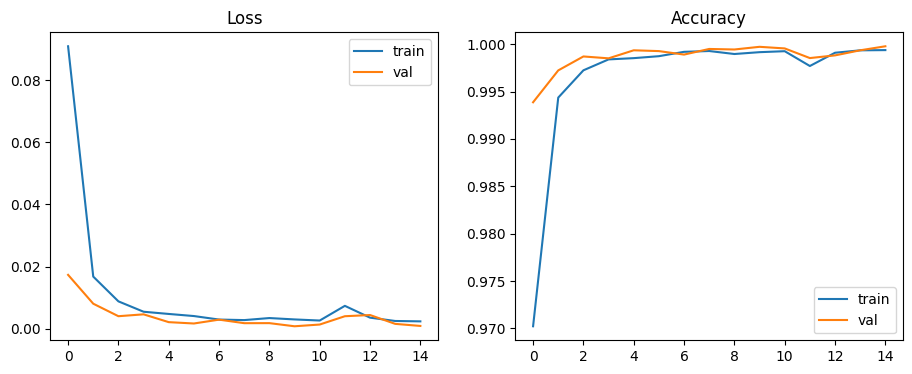

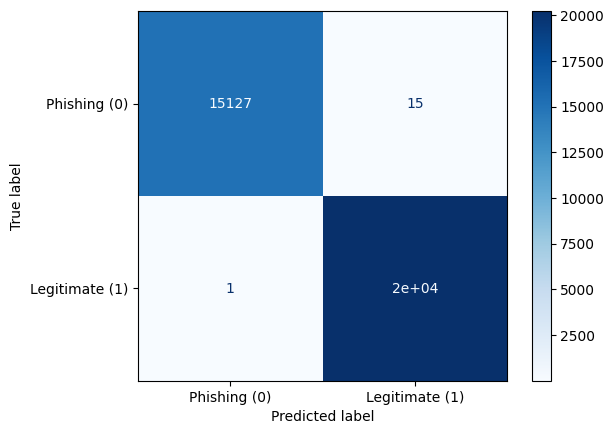

In [3]:
import numpy as np, time, json, random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay)

MODEL_NAME = "lstm"
SEED, BATCH_SIZE, MAX_EPOCHS = 42, 256, 50

random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# 1. load data (already scaled + split by Member 1)
X_train = np.load("X_train.npy"); y_train = np.load("y_train.npy")
X_val   = np.load("X_val.npy");   y_val   = np.load("y_val.npy")
X_test  = np.load("X_test.npy");  y_test  = np.load("y_test.npy")

# 2. reshape (rows, 50) -> (rows, 50, 1)
X_train, X_val, X_test = [x.astype("float32")[..., None] for x in (X_train, X_val, X_test)]

# 3. build model
rnn = layers.LSTM(64) if MODEL_NAME == "lstm" else layers.GRU(64)
model = keras.Sequential([
    layers.Input(shape=(50, 1)),
    rnn,
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.summary()

# 4. train (stops early if val loss stops improving)
early = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
t0 = time.time()
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, callbacks=[early])
train_time = time.time() - t0

# 5. test the model ONE time
proba = model.predict(X_test, batch_size=1024).ravel()
pred = (proba >= 0.5).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
metrics = dict(model=MODEL_NAME, accuracy=accuracy_score(y_test, pred),
               precision=precision_score(y_test, pred), recall=recall_score(y_test, pred),
               f1=f1_score(y_test, pred), roc_auc=roc_auc_score(y_test, proba),
               parameters=model.count_params(), train_time_sec=round(train_time, 1),
               epochs_run=len(history.history["loss"]), TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp))
print(json.dumps(metrics, indent=2))

# 6. graphs
plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1); plt.plot(history.history["loss"], label="train"); plt.plot(history.history["val_loss"], label="val"); plt.title("Loss"); plt.legend()
plt.subplot(1, 2, 2); plt.plot(history.history["accuracy"], label="train"); plt.plot(history.history["val_accuracy"], label="val"); plt.title("Accuracy"); plt.legend()
plt.savefig(f"{MODEL_NAME}_learning_curves.png", dpi=150); plt.show()

ConfusionMatrixDisplay(confusion_matrix(y_test, pred),
                       display_labels=["Phishing (0)", "Legitimate (1)"]).plot(cmap="Blues")
plt.savefig(f"{MODEL_NAME}_confusion_matrix.png", dpi=150); plt.show()

json.dump(metrics, open(f"{MODEL_NAME}_metrics.json", "w"), indent=2)
np.save(f"{MODEL_NAME}_test_proba.npy", proba)
json.dump({k: [float(v) for v in vs] for k, vs in history.history.items()},
          open(f"{MODEL_NAME}_history.json", "w"))